In [2]:
import pandas as pd
import re

from sklearn.model_selection import train_test_split
from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score
from sklearn.metrics import confusion_matrix, classification_report

In [3]:
train_df = pd.read_csv("train.csv")
test_df = pd.read_csv("test.csv")
sample_submission = pd.read_csv("sample_submission.csv")

print("Train shape:", train_df.shape)
print("Test shape:", test_df.shape)
print("Sample submission shape:", sample_submission.shape)

Train shape: (7613, 5)
Test shape: (3263, 4)
Sample submission shape: (3263, 2)


In [4]:
print("\nTrain columns:")
print(train_df.columns)

print("\nFirst 5 rows:")
print(train_df.head())


Train columns:
Index(['id', 'keyword', 'location', 'text', 'target'], dtype='object')

First 5 rows:
   id keyword location                                               text  \
0   1     NaN      NaN  Our Deeds are the Reason of this #earthquake M...   
1   4     NaN      NaN             Forest fire near La Ronge Sask. Canada   
2   5     NaN      NaN  All residents asked to 'shelter in place' are ...   
3   6     NaN      NaN  13,000 people receive #wildfires evacuation or...   
4   7     NaN      NaN  Just got sent this photo from Ruby #Alaska as ...   

   target  
0       1  
1       1  
2       1  
3       1  
4       1  


In [5]:
print("\nMissing values in train:")
print(train_df.isnull().sum())

print("\nMissing values in test:")
print(test_df.isnull().sum())


Missing values in train:
id             0
keyword       61
location    2533
text           0
target         0
dtype: int64

Missing values in test:
id             0
keyword       26
location    1105
text           0
dtype: int64


In [6]:
print("\nClass balance:")
print(train_df["target"].value_counts())

print("\nClass balance percentage:")
print(train_df["target"].value_counts(normalize=True))


Class balance:
target
0    4342
1    3271
Name: count, dtype: int64

Class balance percentage:
target
0    0.57034
1    0.42966
Name: proportion, dtype: float64


In [7]:
def clean_text(text):
    text = str(text).lower()
    text = re.sub(r"http\S+|www\S+", "", text)
    text = re.sub(r"@\w+", "", text)
    text = re.sub(r"#", "", text)
    text = re.sub(r"[^a-zA-Z\s]", "", text)
    text = re.sub(r"\s+", " ", text).strip()
    return text

In [8]:
train_df["clean_text"] = train_df["text"].apply(clean_text)
test_df["clean_text"] = test_df["text"].apply(clean_text)

print("\nOriginal text example:")
print(train_df["text"].iloc[0])

print("\nCleaned text example:")
print(train_df["clean_text"].iloc[0])


Original text example:
Our Deeds are the Reason of this #earthquake May ALLAH Forgive us all

Cleaned text example:
our deeds are the reason of this earthquake may allah forgive us all


In [9]:
X = train_df["clean_text"]
y = train_df["target"]

X_train, X_temp, y_train, y_temp = train_test_split(
    X,
    y,
    test_size=0.30,
    random_state=42,
    stratify=y
)

X_val, X_test, y_val, y_test = train_test_split(
    X_temp,
    y_temp,
    test_size=0.50,
    random_state=42,
    stratify=y_temp
)

print("\nSplit sizes:")
print("Train:", len(X_train))
print("Validation:", len(X_val))
print("Test:", len(X_test))


Split sizes:
Train: 5329
Validation: 1142
Test: 1142


In [10]:
vectorizer = TfidfVectorizer(
    max_features=5000,
    ngram_range=(1, 2)
)

X_train_tfidf = vectorizer.fit_transform(X_train)
X_val_tfidf = vectorizer.transform(X_val)
X_test_tfidf = vectorizer.transform(X_test)

print("\nTF-IDF shapes:")
print("Train:", X_train_tfidf.shape)
print("Validation:", X_val_tfidf.shape)
print("Test:", X_test_tfidf.shape)


TF-IDF shapes:
Train: (5329, 5000)
Validation: (1142, 5000)
Test: (1142, 5000)


In [11]:
baseline_model = LogisticRegression(max_iter=1000)

baseline_model.fit(X_train_tfidf, y_train)

LogisticRegression(max_iter=1000)

In [12]:
val_pred = baseline_model.predict(X_val_tfidf)

print("\nValidation Results:")
print("Accuracy:", round(accuracy_score(y_val, val_pred), 4))
print("Precision:", round(precision_score(y_val, val_pred), 4))
print("Recall:", round(recall_score(y_val, val_pred), 4))
print("F1-score:", round(f1_score(y_val, val_pred), 4))

print("\nValidation Classification Report:")
print(classification_report(y_val, val_pred))

print("\nValidation Confusion Matrix:")
print(confusion_matrix(y_val, val_pred))


Validation Results:
Accuracy: 0.7995
Precision: 0.8149
Recall: 0.6904
F1-score: 0.7475

Validation Classification Report:
              precision    recall  f1-score   support

           0       0.79      0.88      0.83       651
           1       0.81      0.69      0.75       491

    accuracy                           0.80      1142
   macro avg       0.80      0.79      0.79      1142
weighted avg       0.80      0.80      0.80      1142


Validation Confusion Matrix:
[[574  77]
 [152 339]]


In [13]:
test_pred = baseline_model.predict(X_test_tfidf)

print("\nTest Results:")
print("Accuracy:", round(accuracy_score(y_test, test_pred), 4))
print("Precision:", round(precision_score(y_test, test_pred), 4))
print("Recall:", round(recall_score(y_test, test_pred), 4))
print("F1-score:", round(f1_score(y_test, test_pred), 4))

print("\nTest Classification Report:")
print(classification_report(y_test, test_pred))

print("\nTest Confusion Matrix:")
print(confusion_matrix(y_test, test_pred))


Test Results:
Accuracy: 0.817
Precision: 0.8386
Recall: 0.7102
F1-score: 0.7691

Test Classification Report:
              precision    recall  f1-score   support

           0       0.80      0.90      0.85       652
           1       0.84      0.71      0.77       490

    accuracy                           0.82      1142
   macro avg       0.82      0.80      0.81      1142
weighted avg       0.82      0.82      0.81      1142


Test Confusion Matrix:
[[585  67]
 [142 348]]


In [14]:
test_tfidf = vectorizer.transform(test_df["clean_text"])

final_predictions = baseline_model.predict(test_tfidf)

submission = pd.DataFrame({
    "id": test_df["id"],
    "target": final_predictions
})

submission.to_csv("baseline_submission.csv", index=False)

print("\nSubmission saved as:baseline_submission.csv")

print(submission.head())


Submission saved as:baseline_submission.csv
   id  target
0   0       1
1   2       0
2   3       1
3   9       1
4  11       1


# **WEEK3**

In [15]:
import torch
import torch.nn as nn
from torch.utils.data import Dataset, DataLoader
from collections import Counter

device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print("Device:", device)

Device: cpu


In [16]:
# 1. Tokenization

def tokenize(text):
    return str(text).split()

print("Example text:")
print(X_train.iloc[0])

print("\nTokens:")
print(tokenize(X_train.iloc[0]))

Example text:
las vegas in top cities for redlight running fatalities

Tokens:
['las', 'vegas', 'in', 'top', 'cities', 'for', 'redlight', 'running', 'fatalities']


In [17]:
# 2. Build vocabulary from training data

counter = Counter()

for text in X_train:
    counter.update(tokenize(text))

max_vocab_size = 10000

word2idx = {
    "<PAD>": 0,
    "<UNK>": 1
}

for word, count in counter.most_common(max_vocab_size - 2):
    word2idx[word] = len(word2idx)

print("Vocabulary size:", len(word2idx))

Vocabulary size: 10000


In [18]:
# 3. Encode text and add padding

max_len = 40

def encode_text(text):
    tokens = tokenize(text)
    ids = []

    for token in tokens:
        ids.append(word2idx.get(token, word2idx["<UNK>"]))

    if len(ids) < max_len:
        ids = ids + [word2idx["<PAD>"]] * (max_len - len(ids))
    else:
        ids = ids[:max_len]

    return ids

X_train_ids = [encode_text(text) for text in X_train]
X_val_ids = [encode_text(text) for text in X_val]
X_test_ids = [encode_text(text) for text in X_test]

print("Encoded example:")
print(X_train_ids[0])
print("Length:", len(X_train_ids[0]))

Encoded example:
[2595, 2099, 4, 181, 1784, 10, 2100, 767, 412, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0]
Length: 40


In [19]:
# 4. Create PyTorch Dataset

class TweetDataset(Dataset):
    def __init__(self, texts, labels):
        self.texts = torch.tensor(texts, dtype=torch.long)
        self.labels = torch.tensor(labels.values, dtype=torch.long)

    def __len__(self):
        return len(self.labels)

    def __getitem__(self, idx):
        return self.texts[idx], self.labels[idx]

In [20]:
# 5. Create DataLoaders

train_dataset = TweetDataset(X_train_ids, y_train)
val_dataset = TweetDataset(X_val_ids, y_val)
test_dataset = TweetDataset(X_test_ids, y_test)

batch_size = 32

train_loader = DataLoader(train_dataset, batch_size=batch_size, shuffle=True)
val_loader = DataLoader(val_dataset, batch_size=batch_size, shuffle=False)
test_loader = DataLoader(test_dataset, batch_size=batch_size, shuffle=False)

print("Train batches:", len(train_loader))
print("Validation batches:", len(val_loader))
print("Test batches:", len(test_loader))

Train batches: 167
Validation batches: 36
Test batches: 36


In [21]:
class LSTMClassifier(nn.Module):
    def __init__(self, vocab_size, embedding_dim, hidden_dim, output_dim):
        super().__init__()

        self.embedding = nn.Embedding(
            num_embeddings=vocab_size,
            embedding_dim=embedding_dim,
            padding_idx=0
        )

        self.lstm = nn.LSTM(
            input_size=embedding_dim,
            hidden_size=hidden_dim,
            batch_first=True,
            bidirectional=True
        )

        self.dropout = nn.Dropout(0.3)

        self.fc = nn.Linear(hidden_dim * 2, output_dim)

    def forward(self, x):
        embedded = self.embedding(x)

        output, (hidden, cell) = self.lstm(embedded)

        last_hidden = torch.cat((hidden[-2], hidden[-1]), dim=1)

        last_hidden = self.dropout(last_hidden)

        logits = self.fc(last_hidden)

        return logits

In [22]:
# 7. GRU model

class GRUClassifier(nn.Module):
    def __init__(self, vocab_size, embedding_dim, hidden_dim, output_dim):
        super().__init__()

        self.embedding = nn.Embedding(
            num_embeddings=vocab_size,
            embedding_dim=embedding_dim,
            padding_idx=0
        )

        self.gru = nn.GRU(
            input_size=embedding_dim,
            hidden_size=hidden_dim,
            batch_first=True
        )

        self.fc = nn.Linear(hidden_dim, output_dim)

    def forward(self, x):
        embedded = self.embedding(x)
        output, hidden = self.gru(embedded)

        last_hidden = hidden[-1]
        logits = self.fc(last_hidden)

        return logits

In [23]:
# 8. Training function
# We use CrossEntropyLoss because the model predicts 2 classes: 0 and 1.

def train_model(model, train_loader, val_loader, epochs=5):
    model = model.to(device)

    criterion = nn.CrossEntropyLoss()
    optimizer = torch.optim.Adam(model.parameters(), lr=0.001)

    for epoch in range(epochs):
        model.train()
        train_loss = 0

        for texts, labels in train_loader:
            texts = texts.to(device)
            labels = labels.to(device)

            optimizer.zero_grad()

            logits = model(texts)
            loss = criterion(logits, labels)

            loss.backward()
            optimizer.step()

            train_loss += loss.item()

        model.eval()
        val_loss = 0
        correct = 0
        total = 0

        with torch.no_grad():
            for texts, labels in val_loader:
                texts = texts.to(device)
                labels = labels.to(device)

                logits = model(texts)
                loss = criterion(logits, labels)

                val_loss += loss.item()

                preds = torch.argmax(logits, dim=1)

                correct += (preds == labels).sum().item()
                total += labels.size(0)

        avg_train_loss = train_loss / len(train_loader)
        avg_val_loss = val_loss / len(val_loader)
        val_accuracy = correct / total

        print(
            f"Epoch {epoch+1}/{epochs} | "
            f"Train Loss: {avg_train_loss:.4f} | "
            f"Val Loss: {avg_val_loss:.4f} | "
            f"Val Accuracy: {val_accuracy:.4f}"
        )

    return model

In [24]:
# 9. Evaluation function

def evaluate_model(model, data_loader):
    model.eval()

    all_preds = []
    all_labels = []

    with torch.no_grad():
        for texts, labels in data_loader:
            texts = texts.to(device)
            labels = labels.to(device)

            logits = model(texts)

            probs = torch.softmax(logits, dim=1)
            preds = torch.argmax(probs, dim=1)

            all_preds.extend(preds.cpu().numpy())
            all_labels.extend(labels.cpu().numpy())

    acc = accuracy_score(all_labels, all_preds)
    prec = precision_score(all_labels, all_preds)
    rec = recall_score(all_labels, all_preds)
    f1 = f1_score(all_labels, all_preds)

    print("Accuracy:", round(acc, 4))
    print("Precision:", round(prec, 4))
    print("Recall:", round(rec, 4))
    print("F1-score:", round(f1, 4))

    print("\nClassification Report:")
    print(classification_report(all_labels, all_preds))

    print("\nConfusion Matrix:")
    print(confusion_matrix(all_labels, all_preds))

    return acc, prec, rec, f1, all_preds

In [25]:
lstm_model = LSTMClassifier(
    vocab_size=len(word2idx),
    embedding_dim=64,
    hidden_dim=64,
    output_dim=2
)

print(lstm_model)

lstm_model = train_model(
    lstm_model,
    train_loader,
    val_loader,
    epochs=5
)

LSTMClassifier(
  (embedding): Embedding(10000, 64, padding_idx=0)
  (lstm): LSTM(64, 64, batch_first=True, bidirectional=True)
  (dropout): Dropout(p=0.3, inplace=False)
  (fc): Linear(in_features=128, out_features=2, bias=True)
)
Epoch 1/5 | Train Loss: 0.6503 | Val Loss: 0.5749 | Val Accuracy: 0.7128
Epoch 2/5 | Train Loss: 0.5256 | Val Loss: 0.5200 | Val Accuracy: 0.7434
Epoch 3/5 | Train Loss: 0.4287 | Val Loss: 0.5266 | Val Accuracy: 0.7513
Epoch 4/5 | Train Loss: 0.3531 | Val Loss: 0.5116 | Val Accuracy: 0.7723
Epoch 5/5 | Train Loss: 0.2825 | Val Loss: 0.5542 | Val Accuracy: 0.7811


In [26]:
print("LSTM Test Results:")

lstm_accuracy, lstm_precision, lstm_recall, lstm_f1, lstm_preds = evaluate_model(
    lstm_model,
    test_loader
)

LSTM Test Results:
Accuracy: 0.775
Precision: 0.7905
Recall: 0.6469
F1-score: 0.7116

Classification Report:
              precision    recall  f1-score   support

           0       0.77      0.87      0.82       652
           1       0.79      0.65      0.71       490

    accuracy                           0.77      1142
   macro avg       0.78      0.76      0.76      1142
weighted avg       0.78      0.77      0.77      1142


Confusion Matrix:
[[568  84]
 [173 317]]


In [30]:
embedding_dim = 64
hidden_dim = 64
output_dim = 2

# 12. Train GRU

gru_model = GRUClassifier(
    vocab_size=len(word2idx),
    embedding_dim=embedding_dim,
    hidden_dim=hidden_dim,
    output_dim=output_dim
)

print(gru_model)

gru_model = train_model(
    gru_model,
    train_loader,
    val_loader,
    epochs=5
)

GRUClassifier(
  (embedding): Embedding(10000, 64, padding_idx=0)
  (gru): GRU(64, 64, batch_first=True)
  (fc): Linear(in_features=64, out_features=2, bias=True)
)
Epoch 1/5 | Train Loss: 0.6844 | Val Loss: 0.6836 | Val Accuracy: 0.5701
Epoch 2/5 | Train Loss: 0.6824 | Val Loss: 0.6693 | Val Accuracy: 0.5701
Epoch 3/5 | Train Loss: 0.6051 | Val Loss: 0.5658 | Val Accuracy: 0.7277
Epoch 4/5 | Train Loss: 0.4878 | Val Loss: 0.5466 | Val Accuracy: 0.7539
Epoch 5/5 | Train Loss: 0.3891 | Val Loss: 0.5348 | Val Accuracy: 0.7706


In [31]:
# 13. Evaluate GRU

print("GRU Test Results:")

gru_accuracy, gru_precision, gru_recall, gru_f1, gru_preds = evaluate_model(
    gru_model,
    test_loader
)

GRU Test Results:
Accuracy: 0.7653
Precision: 0.7434
Recall: 0.6918
F1-score: 0.7167

Classification Report:
              precision    recall  f1-score   support

           0       0.78      0.82      0.80       652
           1       0.74      0.69      0.72       490

    accuracy                           0.77      1142
   macro avg       0.76      0.76      0.76      1142
weighted avg       0.76      0.77      0.76      1142


Confusion Matrix:
[[535 117]
 [151 339]]


In [32]:
# 14. Compare baseline, LSTM, and GRU

comparison = pd.DataFrame({
    "Model": [
        "Logistic Regression Baseline",
        "LSTM",
        "GRU"
    ],
    "Accuracy": [
        0.8170,
        lstm_accuracy,
        gru_accuracy
    ],
    "Precision": [
        0.8386,
        lstm_precision,
        gru_precision
    ],
    "Recall": [
        0.7102,
        lstm_recall,
        gru_recall
    ],
    "F1-score": [
        0.7691,
        lstm_f1,
        gru_f1
    ]
})

comparison

,Model,Accuracy,Precision,Recall,F1-score
0,Logistic Regression Baseline,0.817000,0.838600,0.710200,0.769100
1,LSTM,0.774956,0.790524,0.646939,0.711560
2,GRU,0.765324,0.743421,0.691837,0.716702


In [33]:
# 15. Error analysis

error_analysis = pd.DataFrame({
    "text": X_test.values,
    "true_label": y_test.values,
    "lstm_prediction": lstm_preds,
    "gru_prediction": gru_preds
})

lstm_errors = error_analysis[
    error_analysis["true_label"] != error_analysis["lstm_prediction"]
]

gru_errors = error_analysis[
    error_analysis["true_label"] != error_analysis["gru_prediction"]
]

print("Number of LSTM errors:", len(lstm_errors))
print("Number of GRU errors:", len(gru_errors))

Number of LSTM errors: 257
Number of GRU errors: 268


In [34]:
print("LSTM error examples:")
display(lstm_errors.head(10))

LSTM error examples:


,text,true_label,lstm_prediction,gru_prediction
1,on the flip side im at walmart and there is a ...,1,0,0
6,i learned more about economics from one south ...,1,0,0
12,tube strike live latest travel updates as lond...,1,0,0
13,spot flood combo inch w curved cree led work l...,1,0,0
21,unpredictable disconnected and social casualty...,1,0,0
23,auction shoes retro fire red,0,1,0
24,zayn malik amp perrie edwards end engagement s...,1,0,1
32,looks like it may have been microsofts anti vi...,0,1,1
33,oh thats not too bad then haha i wouldve been ...,0,1,0
34,hollywood movie about trapped miners released ...,1,0,0


In [35]:
print("GRU error examples:")
display(gru_errors.head(10))

GRU error examples:


,text,true_label,lstm_prediction,gru_prediction
1,on the flip side im at walmart and there is a ...,1,0,0
6,i learned more about economics from one south ...,1,0,0
10,hwrf absolutely lashes taipei with hurricane f...,1,1,0
12,tube strike live latest travel updates as lond...,1,0,0
13,spot flood combo inch w curved cree led work l...,1,0,0
18,is it darude sandstorm,0,0,1
21,unpredictable disconnected and social casualty...,1,0,0
30,turkish couple decided to feed syrian refugees...,0,0,1
31,was in nyc last week,0,0,1
32,looks like it may have been microsofts anti vi...,0,1,1


# **WEEK4**

In [36]:
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score, classification_report

def evaluate_predictions(y_true, y_pred, model_name):
    acc = accuracy_score(y_true, y_pred)
    prec = precision_score(y_true, y_pred)
    rec = recall_score(y_true, y_pred)
    f1 = f1_score(y_true, y_pred)

    print(f"\n===== {model_name} =====")
    print("Accuracy:", round(acc, 4))
    print("Precision:", round(prec, 4))
    print("Recall:", round(rec, 4))
    print("F1-score:", round(f1, 4))
    print("\nClassification Report:")
    print(classification_report(y_true, y_pred))

    return {
        "Model": model_name,
        "Accuracy": acc,
        "Precision": prec,
        "Recall": rec,
        "F1": f1
    }

In [44]:
import torch

def get_dl_predictions(model, dataloader, device):
    model.eval()
    all_preds = []
    all_labels = []

    with torch.no_grad():
        for batch in dataloader:
            inputs, labels = batch # Correctly unpack the tuple
            inputs = inputs.to(device)
            labels = labels.to(device)

            outputs = model(inputs)
            preds = torch.argmax(outputs, dim=1)

            all_preds.extend(preds.cpu().numpy())
            all_labels.extend(labels.cpu().numpy())

    return all_labels, all_preds

In [45]:
lr_pred = baseline_model.predict(X_test_tfidf)

lr_results = evaluate_predictions(
    y_test,
    lr_pred,
    "Logistic Regression TF-IDF"
)


===== Logistic Regression TF-IDF =====
Accuracy: 0.817
Precision: 0.8386
Recall: 0.7102
F1-score: 0.7691

Classification Report:
              precision    recall  f1-score   support

           0       0.80      0.90      0.85       652
           1       0.84      0.71      0.77       490

    accuracy                           0.82      1142
   macro avg       0.82      0.80      0.81      1142
weighted avg       0.82      0.82      0.81      1142



In [46]:
gru_true, gru_pred = get_dl_predictions(
    gru_model,
    test_loader,
    device
)

gru_results = evaluate_predictions(
    gru_true,
    gru_pred,
    "GRU"
)


===== GRU =====
Accuracy: 0.7653
Precision: 0.7434
Recall: 0.6918
F1-score: 0.7167

Classification Report:
              precision    recall  f1-score   support

           0       0.78      0.82      0.80       652
           1       0.74      0.69      0.72       490

    accuracy                           0.77      1142
   macro avg       0.76      0.76      0.76      1142
weighted avg       0.76      0.77      0.76      1142



In [51]:
import pandas as pd

lstm_results = {
    "Model": "LSTM",
    "Accuracy": lstm_accuracy,
    "Precision": lstm_precision,
    "Recall": lstm_recall,
    "F1": lstm_f1
}

results_df = pd.DataFrame([
    lr_results,
    lstm_results,
    gru_results
])

results_df

,Model,Accuracy,Precision,Recall,F1
0,Logistic Regression TF-IDF,0.816988,0.838554,0.710204,0.769061
1,LSTM,0.774956,0.790524,0.646939,0.711560
2,GRU,0.765324,0.743421,0.691837,0.716702


In [55]:
import os

# Create the 'results' directory if it doesn't exist
os.makedirs('results', exist_ok=True)

results_df.to_csv("results/model_comparison.csv", index=False)

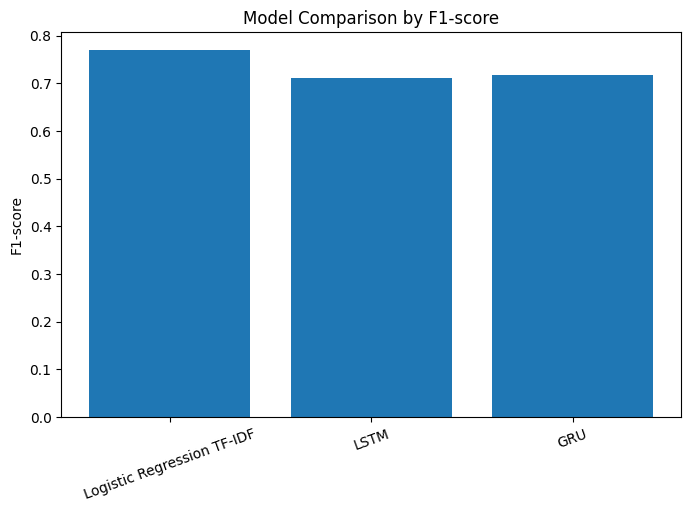

In [56]:
import matplotlib.pyplot as plt

plt.figure(figsize=(8, 5))
plt.bar(results_df["Model"], results_df["F1"])
plt.title("Model Comparison by F1-score")
plt.ylabel("F1-score")
plt.xticks(rotation=20)
plt.show()

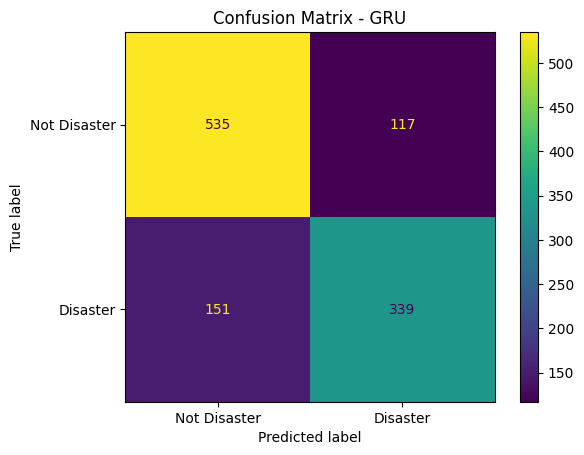

In [57]:
from sklearn.metrics import confusion_matrix, ConfusionMatrixDisplay

cm = confusion_matrix(gru_true, gru_pred)

disp = ConfusionMatrixDisplay(
    confusion_matrix=cm,
    display_labels=["Not Disaster", "Disaster"]
)

disp.plot()
plt.title("Confusion Matrix - GRU")
plt.show()

In [59]:
errors = []

for text, true_label, pred_label in zip(X_test, gru_true, gru_pred):
    if true_label != pred_label:
        errors.append({
            "text": text,
            "true_label": true_label,
            "predicted_label": pred_label
        })

errors_df = pd.DataFrame(errors)
errors_df.head(10)

,text,true_label,predicted_label
0,on the flip side im at walmart and there is a ...,1,0
1,i learned more about economics from one south ...,1,0
2,hwrf absolutely lashes taipei with hurricane f...,1,0
3,tube strike live latest travel updates as lond...,1,0
4,spot flood combo inch w curved cree led work l...,1,0
5,is it darude sandstorm,0,1
6,unpredictable disconnected and social casualty...,1,0
7,turkish couple decided to feed syrian refugees...,0,1
8,was in nyc last week,0,1
9,looks like it may have been microsofts anti vi...,0,1


In [60]:
errors_df.to_csv("results/error_analysis.csv", index=False)

In [61]:
best_model = results_df.sort_values("F1", ascending=False).iloc[0]

print("Best model:", best_model["Model"])
print("Best F1-score:", round(best_model["F1"], 4))

Best model: Logistic Regression TF-IDF
Best F1-score: 0.7691


In [63]:
lr_errors = []

for text, true_label, pred_label in zip(X_test, y_test, lr_pred):
    if true_label != pred_label:
        lr_errors.append({
            "text": text,
            "true_label": true_label,
            "predicted_label": pred_label
        })

lr_errors_df = pd.DataFrame(lr_errors)
lr_errors_df.head(10)

,text,true_label,predicted_label
0,on the flip side im at walmart and there is a ...,1,0
1,tube strike live latest travel updates as lond...,1,0
2,spot flood combo inch w curved cree led work l...,1,0
3,unpredictable disconnected and social casualty...,1,0
4,auction shoes retro fire red,0,1
5,zayn malik amp perrie edwards end engagement s...,1,0
6,was in nyc last week,0,1
7,hollywood movie about trapped miners released ...,1,0
8,russia may have played into reason but that li...,1,0
9,growth dries up for bhp billiton as oil price ...,0,1


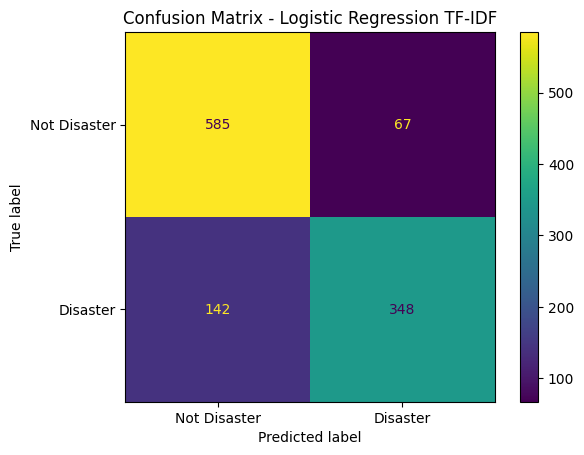

In [64]:
cm = confusion_matrix(y_test, lr_pred)

disp = ConfusionMatrixDisplay(
    confusion_matrix=cm,
    display_labels=["Not Disaster", "Disaster"]
)

disp.plot()
plt.title("Confusion Matrix - Logistic Regression TF-IDF")
plt.show()

In [65]:
lr_errors_df.to_csv("results/best_model_error_analysis.csv", index=False)